# 02: Volt-Watt and Volt-VAr conformance and curtailment

This notebook keeps three questions separate: 
- **maximum-output or required-Q conformance**, 
- **whether the observation was informative about an active response**, and 
- **counterfactual-supported curtailed energy**. 

The 10% site threshold is a project reporting convention, not a tolerance granted by AS/NZS 4777.2.

## Interpretation

- Volt-Watt conformance asks whether measured P exceeded the voltage-dependent maximum. It does not require a counterfactual.
- Volt-Watt response support asks whether measured P already proved a violation or the counterfactual showed enough solar resource to test the response.
- Curtailment energy is calculated only on intervals with a counterfactual. Missing counterfactuals are reported, never replaced with zero.
- Volt-VAr conformance uses the Stage 2 capability-assessable denominator. Low-power intervals excluded by Section 2.6 (Figure 2.1) of AS/NZ 4777.2.2020 implementation are reported separately.

In [1]:
%matplotlib inline

import importlib
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Locate the repository.
HERE = Path.cwd().resolve()

REPO_ROOT = next(
    (
        path
        for path in (HERE, *HERE.parents)
        if (path / "bms_sa_review").is_dir()
    ),
    None,
)

if REPO_ROOT is None:
    raise RuntimeError(
        "Cannot find the repository root containing bms_sa_review. "
        f"Current directory: {HERE}"
    )


# Expose all import styles currently used in the repository.
PACKAGE_ROOT = REPO_ROOT / "bms_sa_review"
SHARED = PACKAGE_ROOT / "shared"
LIB = PACKAGE_ROOT / "data_query" / "lib"

for path in (REPO_ROOT, PACKAGE_ROOT, SHARED, LIB):
    path_string = str(path)

    if path_string not in sys.path:
        sys.path.insert(0, path_string)


# Project imports.
from bms_sa_review.shared.aws_config import aq

import analysis_contract as contract
import conformance_queries as cq
import conformance_metrics as cm
import conformance_plots as cp


# Reload local analytical modules during notebook development.
for module in (contract, cq, cm, cp):
    importlib.reload(module)


pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

print("Repository root:", REPO_ROOT)
print("Package root:", PACKAGE_ROOT)
print("Shared modules:", SHARED)
print("Analysis library:", LIB)

Repository root: C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA
Package root: C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA\bms_sa_review
Shared modules: C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA\bms_sa_review\shared
Analysis library: C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA\bms_sa_review\data_query\lib


In [2]:
# Running for FLEX included tables:
FLEX_INCLUDED_TABLES = dict(contract.TABLES)

FLEX_INCLUDED_TABLES.update({
    "structured_data": "structured_data_v2_flex_included",
    "all_uncurtailedpv": "all_uncurtailedpv_v2_flex_included",
    "conformance_voltwatt": "conformance_voltwatt_v2_flex_included",
    "conformance_voltwattghi": "conformance_voltwattghi_v2_flex_included",
    "conformance_voltvar": "conformance_voltvar_v2_flex_included",
})

CONFIG = contract.AnalysisConfig(
    years=(2024, 2025),
    flex_selection="include",
    rating_basis="ac_capacity_kw",
    empirical_limit_basis="s_99",
    voltage_aggregation="avg",
    capability_profile="review_corrected",
    day_night="all",
    tables=FLEX_INCLUDED_TABLES,
).validate()

display(contract.manifest(CONFIG))

,setting,value
0,database,solar_analytics_iceberg
1,years,"2024, 2025"
2,interval_minutes,5.0
3,site_nonconf_threshold,0.1
4,minimum_site_intervals,1
5,flex_selection,include
6,rating_basis,ac_capacity_kw
7,empirical_limit_basis,s_99
8,voltage_aggregation,avg
9,capability_profile,review_corrected


## 1. Inputs, stored provenance, and metadata integrity

In [3]:
inventory = cq.fetch_inventory(aq, CONFIG)
stored_provenance = cq.fetch_stored_provenance(aq, CONFIG)
display(inventory)
display(stored_provenance)

meta = cq.fetch_metadata(aq, CONFIG)
meta_conflicts = cm.validate_metadata(meta)
display(meta_conflicts)
assert not meta['site_id'].duplicated().any()

,logical_name,table_name,n_rows,n_sites,first_year,last_year
0,structured_data,structured_data_v2_flex_included,871655350,15993,2024,2025
1,all_uncurtailedpv,all_uncurtailedpv_v2_flex_included,504416916,15888,2024,2025
2,conformance_voltvar,conformance_voltvar_v2_flex_included,15653733,16148,2024,2025
3,conformance_voltwatt,conformance_voltwatt_v2_flex_included,15653733,16148,2024,2025
4,conformance_voltwattghi,conformance_voltwattghi_v2_flex_included,15653733,16148,2024,2025


,table_name,normalization_basis,voltage_aggregation,flex_selection,n_rows,counterfactual_cap_basis,rating_basis,empirical_limit_basis,capability_profile
0,structured_data_v2_flex_included,s_99,avg,include,871655350,<NA>,<NA>,<NA>,<NA>
1,all_uncurtailedpv_v2_flex_included,s_99,<NA>,<NA>,504416916,none,<NA>,<NA>,<NA>
2,conformance_voltwatt_v2_flex_included,<NA>,avg,include,15653733,<NA>,ac_capacity_kw,<NA>,<NA>
3,conformance_voltwattghi_v2_flex_included,<NA>,avg,include,15653733,<NA>,ac_capacity_kw,<NA>,<NA>
4,conformance_voltvar_v2_flex_included,<NA>,avg,include,15653733,<NA>,ac_capacity_kw,s_99,review_corrected


,field,sites_with_multiple_values
0,n_state_values,0
1,n_dnsp_values,0
2,n_oem_values,0
3,n_ac_capacity_values,0
4,n_s99_values,0


In [4]:
population_funnel = cq.fetch_population_funnel(aq, CONFIG)
display(population_funnel.T.rename(columns={0: 'n_sites'}))

,n_sites
sites_in_stage2,16148
vw_voltage_exposed_sites,5021
vw_counterfactual_present_sites,3637
vw_response_supported_sites,1971
vw_sites_with_missing_counterfactual,4549
vv_voltage_exposed_sites,16078
vv_capability_assessable_sites,16148
vv_apparent_limit_symptom_sites,7541


## 2. Volt-Watt maximum-output conformance

**Question:** when voltage selected a reduced maximum active-power level, did measured P exceed that permitted maximum (including the stored ±4% band)? A below-ceiling observation satisfies this maximum-output test but does not, by itself, demonstrate active curtailment.

In [5]:
#### Parameters presented below ####
# n_sites = The number of distinct sites with at least one evaluated Volt-Watt interval.
# n_intervals = The total number of five-minute site intervals where *average* site voltage was greater than 253 V.
# n_nonconforming_intervals = The number of voltage-exposed intervals where measured active power exceeded the permitted Volt-Watt maximum: P_measured > P_VW_curve(V) + 0.04 × ac_capacity_kw
# interval_nonconf_pct = 100 × n_nonconforming_intervals / n_intervals

#### Agreggations ####
# fleet_conformant_pct:
## First, a nonconformance fraction is calculated separately for each site: site nonconformance fraction = site nonconforming intervals / site exposed intervals
## The project rule then classifies a site as conformant when: site nonconformance fraction < 10%
## fleet_conformant_pct is the percentage of evaluated sites satisfying that rule: fleet_conformant_pct = 100 × conformant sites / evaluated sites

# fleet_any_nonconf_pct
## The percentage of evaluated sites with at least one nonconforming interval:
## fleet_any_nonconf_pct = 100 × sites with at least one nonconforming interval / evaluated sites

In [6]:
vw_site_year = cq.fetch_vw_site_year(aq, CONFIG)
vw_sites = cm.prepare_vw_conformance(vw_site_year, CONFIG)
vw_table_sites = vw_site_year["site_id"].nunique()
vw_result = cm.fleet_result(
    vw_sites,
    "Volt-Watt maximum-output conformance",
    "Did measured P exceed the voltage-dependent maximum?",
    "voltage-exposed intervals (V > 253 V)",
    table_site_count=vw_table_sites,
)

# Did measured P exceed the voltage-dependent maximum?
display(vw_result)
display(vw_sites.sort_values('nonconf_frac', ascending=False).head(20))

,metric,question,denominator,n_sites_contained_in_table,n_assessed_sites,n_intervals,n_nonconforming_intervals,interval_nonconf_pct,fleet_conformant_pct,fleet_any_nonconf_pct
0,Volt-Watt maximum-output conformance,Did measured P exceed the voltage-dependent ma...,voltage-exposed intervals (V > 253 V),16148,5021,6832290,872922,12.776419,84.564828,28.679546


,site_id,all_intervals_count,exposed_count,nonconf_count,nonconf_kw_sum,denominator_count,nonconf_frac,conformant,nonconformant,any_nonconformance
7740,1032979049,179198,1,1,1.324310,1,1.0,False,True,True
2040,267756219,208069,1,1,0.421600,1,1.0,False,True,True
2036,267013351,197802,1,1,1.691880,1,1.0,False,True,True
8153,1087548303,201602,1,1,0.442240,1,1.0,False,True,True
15688,2083751969,100023,1,1,3.513810,1,1.0,False,True,True
15673,2080796628,202036,1,1,0.512470,1,1.0,False,True,True
3431,458005374,189670,13,13,18.632630,13,1.0,False,True,True
7989,1067737143,38742,1,1,3.621573,1,1.0,False,True,True
7961,1061280236,175638,1,1,0.461919,1,1.0,False,True,True
7634,1018161697,160877,1,1,3.848040,1,1.0,False,True,True


### Normalised magnitude of Volt-Watt nonconformance

The site-conformance result above measures the frequency of nonconformance. The following metric additionally measures its magnitude.

For each site, nonconforming kW samples are converted to Wh and normalised by AC nameplate capacity and the number of voltage-exposed intervals:

`normalised NC = nonconformance Wh / (ac_capacity_kw × exposed intervals)`

The resulting unit is Wh per kW-nameplate per exposed interval. This is a severity metric and does not replace the 10% frequency-based site classification.

In [7]:
vw_sites_normalized = cm.add_vw_normalized_nonconformance(
    vw_sites,
    meta,
    CONFIG.interval_h,
    capacity_col="ac_capacity_kw",
)

display(
    vw_sites_normalized[
        [
            "site_id",
            "nonconf_count",
            "denominator_count",
            "nonconformance_wh",
            "normalized_nonconformance_wh_per_kw_interval",
        ]
    ]
    .sort_values(
        "normalized_nonconformance_wh_per_kw_interval",
        ascending=False,
    )
    .head(20)
)

,site_id,nonconf_count,denominator_count,nonconformance_wh,normalized_nonconformance_wh_per_kw_interval
1924,849625329,1,1,331.570833,66.314167
2870,1250978677,1,1,327.630833,65.526167
4008,1719859299,1,1,654.293333,65.429333
3291,1429056724,1,1,368.297500,61.382917
322,139776191,1,1,546.392500,60.710278
3205,1393747477,1,1,600.118333,60.011833
1067,468804908,1,1,298.085833,59.617167
101,41701698,1,1,295.145833,59.029167
2659,1164269578,1,1,294.708333,58.941667
2194,958447955,1,1,286.746667,57.349333


In [8]:
vw_sites_normalized[vw_sites_normalized['nonconformant'] == True]

,site_id,all_intervals_count,exposed_count,nonconf_count,nonconf_kw_sum,denominator_count,nonconf_frac,conformant,nonconformant,any_nonconformance,ac_capacity_kw,nonconformance_wh,capacity_interval_exposure_kw,normalized_nonconformance_wh_per_kw_interval
4,1776255,16490,110,23,8.627035,110,0.209091,False,True,True,5.00,7.189196e+02,550.0,1.307127
5,2063970,40546,58,23,23.305060,58,0.396552,False,True,True,6.24,1.942088e+03,361.92,5.366071
7,2934556,208253,7,3,5.688962,7,0.428571,False,True,True,10.00,4.740802e+02,70.0,6.772574
11,5609143,52718,2,1,0.316861,2,0.5,False,True,True,9.00,2.640512e+01,18.0,1.466951
12,5822349,208147,36,13,4.448287,36,0.361111,False,True,True,5.00,3.706906e+02,180.0,2.059392
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4989,2133388450,208465,8,1,0.882084,8,0.125,False,True,True,6.00,7.350699e+01,48.0,1.531396
4990,2134086510,206587,23101,8514,17076.787398,23101,0.368555,False,True,True,10.00,1.423066e+06,231010.0,6.160191
5005,2142264523,159481,119,32,15.715244,119,0.268908,False,True,True,5.00,1.309604e+03,595.0,2.201015
5014,2146606718,118392,39,10,1.454336,39,0.25641,False,True,True,4.99,1.211946e+02,194.61,0.622757


## 3. Volt-Watt response support and counterfactual coverage

This is a narrower evidentiary population, not a replacement compliance population. 

An interval is response-supported when actual P proves a violation or the counterfactual exceeds the permitted maximum.

In [9]:
#### Parameters presented below ####

# exposed_intervals = All five-minute intervals where average site voltage was greater than 253 V

# response_supported_intervals:
## An exposed interval is response-supported when either:
## measured P exceeded the permitted Volt-Watt maximum, establishing a definite violation; or
## counterfactual P exceeded the permitted maximum, showing that sufficient solar power was available to test the response.

# missing_counterfactual_intervals = The number of voltage-exposed intervals for which all_uncurtailedpv_v2 supplied no matching counterfactual estimate

# response_supported_pct_of_exposed = 100 × response-supported intervals / exposed intervals
# missing_counterfactual_pct_of_exposed = 100 × missing-counterfactual intervals / exposed intervals 

#### Aggregations ####
# interval_nonconf_pct = 100 × nonconforming intervals / response-supported intervals
### This is not be presented as the fleet-wide Volt-Watt nonconformance rate.
### It is high because:
### - every measured violation enters the response-supported population;
### - a below-limit observation enters only when the counterfactual proves that enough solar power was available to test the response. 

# fleet_conformant_pct:
## For each response-supported site:
## site response-supported nonconformance fraction = site nonconforming intervals / site response-supported intervals
## The same project threshold is then applied:
## conformant if site fraction < 10% 
## (This is not the primary fleet conformance result. It is a narrower result among sites where at least one informative response verdict was available.)

# fleet_any_nonconf_pct
## The percentage of response-supported sites with at least one directly observed violation:
## fleet_any_nonconf_pct = 100 × response-supported sites with any violation / all response-supported sites

In [10]:
vwg_site_year = cq.fetch_vw_response_site_year(aq, CONFIG)
vwg_sites = cm.prepare_vw_response(vwg_site_year, CONFIG)
vwg_table_sites = vwg_site_year["site_id"].nunique()
vwg_result = cm.fleet_result(
    vwg_sites,
    "Volt-Watt response-supported result",
    "Was enough solar power available to test the response, or was a violation directly observed?",
    "response-supported intervals",
    table_site_count=vwg_table_sites,
)

# Was enough solar power available to test the response, or was a violation directly observed?
display(cm.coverage_summary(vwg_site_year))
display(vwg_result)
membership = vw_sites[['site_id']].merge(vwg_sites[['site_id']], on='site_id', how='outer', indicator=True)
display(membership['_merge'].value_counts().rename_axis('membership').to_frame('n_sites'))

,exposed_intervals,response_supported_intervals,missing_counterfactual_intervals,response_supported_pct_of_exposed,missing_counterfactual_pct_of_exposed
0,6832287,951407,4241323,13.925162,62.077647


,metric,question,denominator,n_sites_contained_in_table,n_assessed_sites,n_intervals,n_nonconforming_intervals,interval_nonconf_pct,fleet_conformant_pct,fleet_any_nonconf_pct
0,Volt-Watt response-supported result,Was enough solar power available to test the r...,response-supported intervals,16148,1971,951407,872922,91.750639,31.100964,73.059361


,n_sites
membership,
left_only,3050
both,1971
right_only,0


In [11]:
vw_magnitude_sites = cm.vw_nonconformance_magnitude(
    vw_sites,
    meta,
    CONFIG.interval_h,
    capacity_col="ac_capacity_kw",
)

vw_magnitude_fleet = pd.DataFrame([{
    "n_sites": vw_magnitude_sites["site_id"].nunique(),

    "assessed_intervals":
        int(vw_magnitude_sites["denominator_count"].sum()),

    "nonconforming_intervals":
        int(vw_magnitude_sites["nonconf_count"].sum()),

    "nonconforming_kwh":
        vw_magnitude_sites["nonconforming_kwh"].sum(),

    "fleet_weighted_nonconforming_kwh_per_kw_interval": (
        vw_magnitude_sites["nonconforming_kwh"].sum()
        / vw_magnitude_sites[
            "capacity_interval_exposure_kw"
        ].sum()
    ),
}])

display(vw_magnitude_fleet)

display(
    vw_magnitude_sites[
        [
            "site_id",
            "nonconf_count",
            "denominator_count",
            "nonconforming_kwh",
            "ac_capacity_kw",
            "normalized_nonconformance_kwh_per_kw_interval",
        ]
    ]
    .sort_values("nonconforming_kwh", ascending=False)
    .head(20)
)

,n_sites,assessed_intervals,nonconforming_intervals,nonconforming_kwh,fleet_weighted_nonconforming_kwh_per_kw_interval
0,5021,6832290,872922,129209.256815,0.001943


,site_id,nonconf_count,denominator_count,nonconforming_kwh,ac_capacity_kw,normalized_nonconformance_kwh_per_kw_interval
1059,465008538,27605,94295,7451.933760,8.00,0.009878
1846,814602644,21938,34117,6456.156525,10.00,0.018924
1714,755163749,19287,29430,6272.757251,10.00,0.021314
4307,1837079785,20179,34609,6141.042623,10.00,0.017744
1383,615902948,12612,15768,5044.253288,10.00,0.031990
4611,1973437094,16364,25084,4592.028209,10.00,0.018307
4114,1759001229,13298,21842,3996.624069,10.00,0.018298
3637,1559806445,14452,28254,3860.140174,10.00,0.013662
1372,609703575,13196,22651,3136.140786,10.00,0.013845
3395,1473085105,14178,26927,2845.612065,10.00,0.010568


### Volt-Watt conformance breakdown

In [12]:
vw_magnitude_breakdowns = {}

for group in ("state", "dnsp", "oem", "install_year"):
    vw_magnitude_breakdowns[group] = (
        cm.vw_nonconformance_magnitude_breakdown(
            vw_sites,
            meta,
            group,
            CONFIG.interval_h,
            capacity_col="ac_capacity_kw",
            min_sites=20,
        )
    )

    print(f"\nVolt-Watt nonconformance magnitude by {group}")
    display(vw_magnitude_breakdowns[group])


Volt-Watt nonconformance magnitude by state


,state,n_sites,assessed_intervals,nonconforming_intervals,nonconforming_kwh,capacity_interval_exposure_kw,mean_site_normalized_nonconformance,median_site_normalized_nonconformance,interval_nonconf_pct,fleet_weighted_nonconforming_kwh_per_kw_interval
3,QLD,1990,3039947,609129,100514.046850,28845107.22,0.003528,0.0,20.037487,0.003485
4,SA,320,297732,32366,3618.548473,2082862.55,0.000607,0.0,10.87085,0.001737
1,NSW,1875,2786717,198334,22458.125953,27512747.59,0.000629,0.0,7.11712,0.000816
0,ACT,80,49036,4576,211.285235,343259.8,0.000159,0.0,9.331919,0.000616
7,WA,171,233010,21874,2138.578675,4276534.48,0.000459,0.0,9.38758,0.0005
2,NT,68,78623,4380,142.814400,471240.8,0.000136,0.0,5.570889,0.000303
6,VIC,443,299664,1903,111.416158,2626403.63,0.000499,0.0,0.635045,0.000042
5,TAS,74,47561,360,14.441070,350839.5,0.002545,0.0,0.756923,0.000041



Volt-Watt nonconformance magnitude by dnsp


,dnsp,n_sites,assessed_intervals,nonconforming_intervals,nonconforming_kwh,capacity_interval_exposure_kw,mean_site_normalized_nonconformance,median_site_normalized_nonconformance,interval_nonconf_pct,fleet_weighted_nonconforming_kwh_per_kw_interval
6,Ergon,1320,2822275,591121,100535.666722,29437461.65,0.002453,0.0,20.944841,0.003415
11,SAPN,311,285336,31492,3575.999304,1898523.55,0.000434,0.0,11.036813,0.001884
7,Essential,634,1148194,93852,11559.487562,11063216.88,0.000854,0.0,8.17388,0.001045
1,Ausgrid,849,1294994,90530,9675.518564,11141874.09,0.001247,0.0,6.990766,0.000868
0,Actewagl,80,49036,4576,211.285235,343259.8,0.000159,0.0,9.331919,0.000616
5,Energex,614,292500,25600,1373.539725,2511625.07,0.005617,0.0,8.752137,0.000547
13,Unknown,200,182978,14117,464.371832,1196260.68,0.000164,0.0,7.715135,0.000388
4,Endeavour,458,395115,18375,1662.050406,5809984.62,0.000268,0.0,4.650545,0.000286
14,Western Power,37,17497,976,25.740139,130468.3,0.000149,0.0,5.578099,0.000197
15,united energy,93,14680,111,10.623761,173128.24,0.000131,0.0,0.756131,0.000061



Volt-Watt nonconformance magnitude by oem


,oem,n_sites,assessed_intervals,nonconforming_intervals,nonconforming_kwh,capacity_interval_exposure_kw,mean_site_normalized_nonconformance,median_site_normalized_nonconformance,interval_nonconf_pct,fleet_weighted_nonconforming_kwh_per_kw_interval
11,GoodWe,736,1537223,350094,69438.669900,14192358.2,0.000939,0.0,22.774445,0.004893
9,Generic Inverter,1671,1750374,164781,24370.415057,15414902.91,0.004370,0.0,9.414045,0.001581
7,Fronius,847,1129214,148434,12237.629447,9036870.5,0.000627,0.0,13.144895,0.001354
27,Sungrow,833,1410134,181390,21200.759590,18407841.18,0.000289,0.0,12.863317,0.001152
26,Solis,57,46348,3662,619.567028,623989.1,0.000339,0.0,7.901096,0.000993
29,Zeversolar,25,28518,971,58.555447,137587.0,0.000105,0.0,3.404867,0.000426
12,Growatt,24,27279,1643,52.890929,135189.0,0.000234,0.0,6.022948,0.000391
24,SolaX,175,144851,2522,118.092673,704486.3,0.000060,0.0,1.741099,0.000168
19,SMA,365,392498,8804,450.039797,3705576.0,0.000233,0.0,2.243069,0.000121
0,ABB,66,143861,2589,110.146853,1944858.9,0.000033,0.0,1.799654,0.000057



Volt-Watt nonconformance magnitude by install_year


,install_year,n_sites,assessed_intervals,nonconforming_intervals,nonconforming_kwh,capacity_interval_exposure_kw,mean_site_normalized_nonconformance,median_site_normalized_nonconformance,interval_nonconf_pct,fleet_weighted_nonconforming_kwh_per_kw_interval
13,2022,662,1124004,231926,47018.935422,10103164.06,0.000749,0.0,20.633912,0.004654
9,2018,143,119297,17689,3150.839191,753481.58,0.000380,0.0,14.827699,0.004182
11,2020,921,1275037,187702,21266.624551,9196892.95,0.000547,0.0,14.721298,0.002312
12,2021,882,1696676,263425,38869.567870,19627915.48,0.000537,0.0,15.525946,0.00198
15,2024,864,1007711,101859,11622.852356,9728709.87,0.005575,0.0,10.107958,0.001195
10,2019,473,337088,25622,1688.762131,2477788.76,0.000292,0.0,7.600983,0.000682
16,2025,265,166411,5349,602.249290,1302453.49,0.000192,0.0,3.214331,0.000462
14,2023,663,915672,32475,4662.390904,11081679.87,0.003529,0.0,3.546576,0.000421
7,2016,44,17053,539,33.990808,90044.6,0.000112,0.0,3.160734,0.000377
8,2017,61,103876,4243,109.104085,774406.61,0.000203,0.0,4.084678,0.000141


### Minimum intervals sensitivity

minimum_intervals is a site-inclusion threshold. It does not replace or change the 10% rule. For example:
- minimum 1: include any site with at least one evaluated interval;
- minimum 10: include only sites with at least 10 evaluated intervals;
- minimum 100: include only sites with at least 100 evaluated intervals.

After applying that inclusion criterion, the same site rule remains: {conformant if < 10%; nonconformant if >= 10%} 


This matters because classifications based on very few observations are unstable:
- 1 violation out of 1 interval = 100% and nonconformant;
- 1 violation out of 10 intervals = 10% and nonconformant;
- 2 violations out of 10 intervals = 20% and nonconformant;
- 10 violations out of 100 intervals = 10% and nonconformant.

,minimum_intervals,n_sites,fleet_conformant_pct,median_nonconf_frac
0,1,5021,84.564828,0.000000
1,5,3769,86.044044,0.000000
2,10,3318,85.714286,0.000000
3,30,2778,84.161267,0.000000
4,100,2082,81.940442,0.000000
5,300,1516,79.287599,0.000089


,minimum_intervals,n_sites,fleet_conformant_pct,median_nonconf_frac
0,1,1971,31.100964,0.951303
1,5,1128,29.255319,0.907275
2,10,959,26.485923,0.925926
3,30,691,22.141823,0.942857
4,100,454,13.215859,0.959609
5,300,302,6.291391,0.967513


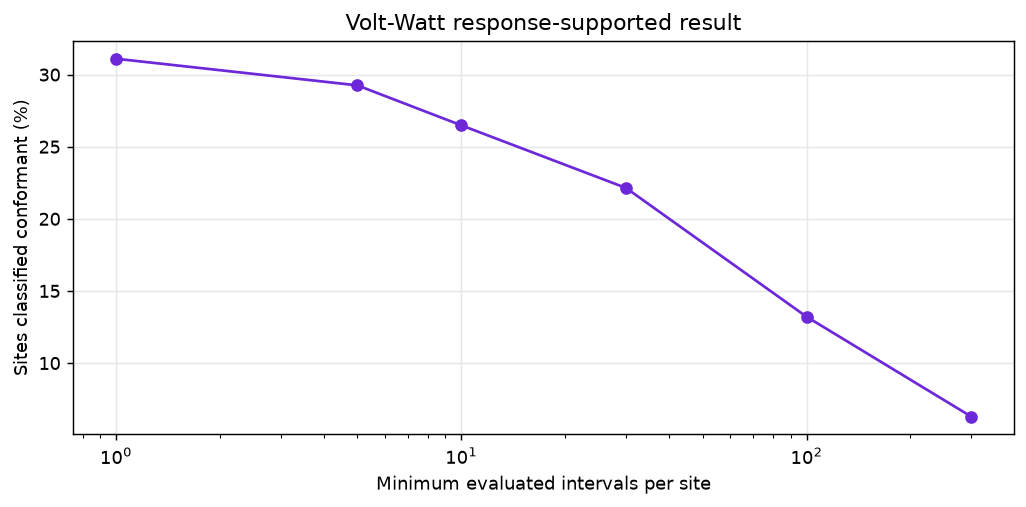

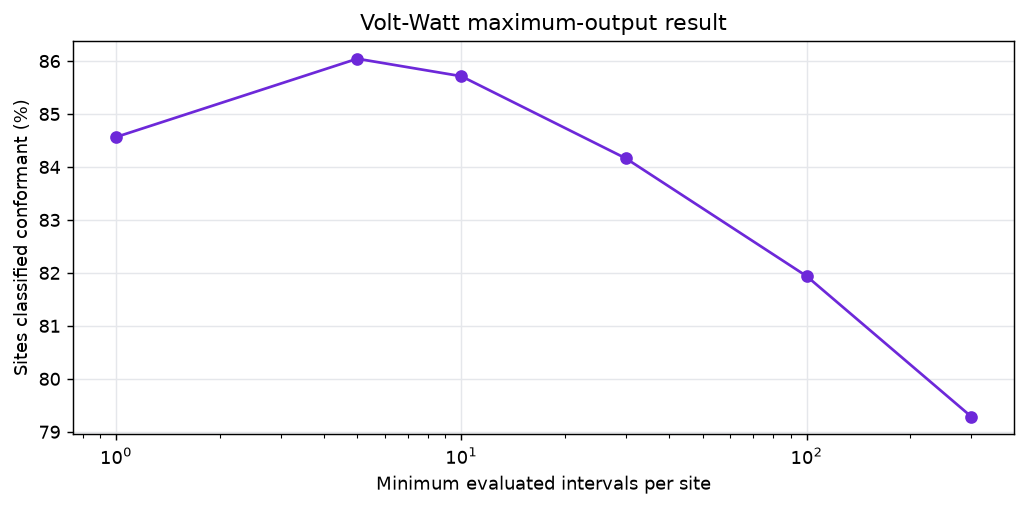

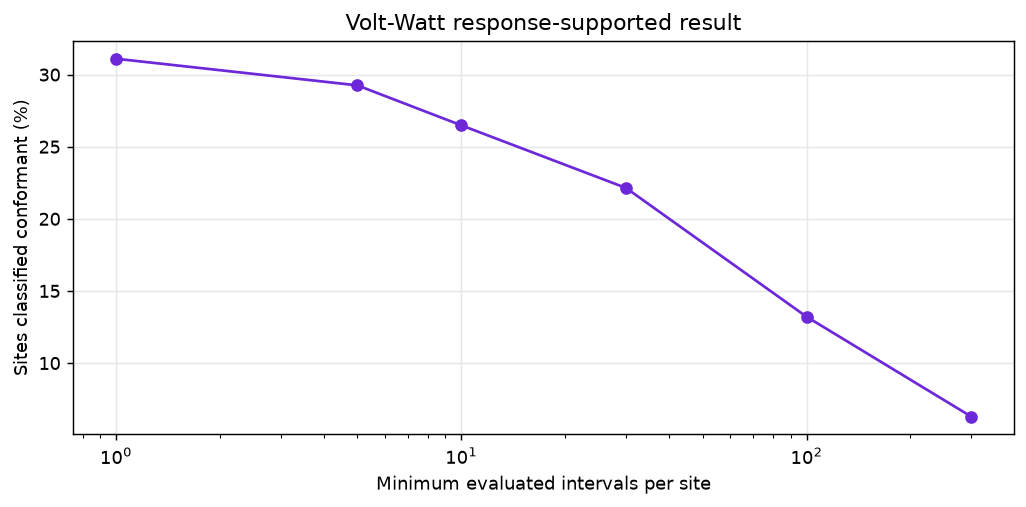

In [13]:
vw_sensitivity = cm.minimum_interval_sensitivity(
    vw_site_year, 'nonconf_count', 'exposed_count', CONFIG)
vwg_sensitivity = cm.minimum_interval_sensitivity(
    vwg_site_year, 'nonconf_count', 'response_supported_count', CONFIG)
display(vw_sensitivity)
display(vwg_sensitivity)
cp.plot_sensitivity(vw_sensitivity, 'Volt-Watt maximum-output result')
cp.plot_sensitivity(vwg_sensitivity, 'Volt-Watt response-supported result')

## 4. Volt-Watt curtailed energy

Energy is reported only for counterfactual-covered intervals where potential P exceeded the permitted maximum and measured P did not. Five-minute kW samples are multiplied by 1/12 to obtain kWh.

The Stage 1 counterfactual table is a quality-gated modelling product rather than a complete copy of the telemetry time series. A counterfactual is written only when the site passes the MAPE gate, a structured-data and clear-sky reference is available, the interval passes the irradiance and generation filters, and a sufficiently trained time-of-day model is available. Consequently, an exposed interval may retain valid voltage and measured-power telemetry but have no counterfactual estimate. Missing counterfactuals reduce the coverage of response-opportunity and curtailed-energy analyses; they do not remove the interval from the basic maximum-output conformance analysis.

In [14]:
vw_energy_site_year = cq.fetch_vw_energy_site_year(aq, CONFIG)
vw_energy_sites, vw_energy_summary = cm.energy_summary(
    vw_energy_site_year, CONFIG.interval_h, 'Volt-Watt counterfactual curtailment')
display(vw_energy_summary)
display(vw_energy_sites.sort_values('curtailed_kwh', ascending=False).head(20))

,metric,year,counterfactual_covered_sites,counterfactual_voltage_exposed_sites,response_opportunity_sites,curtailed_sites,counterfactual_covered_intervals,counterfactual_voltage_exposed_intervals,response_opportunity_intervals,curtailed_intervals,curtailed_kwh,total_measured_generation_kwh,total_counterfactual_generation_kwh,curtailed_interval_counterfactual_kwh,curtailed_pct_within_curtailed_intervals,curtailed_pct_of_total_counterfactual_generation,curtailed_pct_of_measured_plus_vw_loss
0,Volt-Watt counterfactual curtailment,2024,14315,2760,1089,963,271817416,1459985,245914,42953,4819.740389,1.029418e+08,1.175419e+08,23174.469190,20.797630,0.004100,0.004682
1,Volt-Watt counterfactual curtailment,2025,13308,2464,1053,785,232333392,1130979,179379,35532,3661.094528,9.372492e+07,1.068223e+08,19597.345759,18.681584,0.003427,0.003906


,site_id,year,counterfactual_covered_count,counterfactual_exposed_count,response_opportunity_count,curtailed_count,curtailed_kw_sum,measured_kw_sum,potential_kw_sum,curtailed_interval_measured_kw_sum,curtailed_interval_potential_kw_sum,curtailed_kwh,measured_kwh,potential_kwh,curtailed_interval_measured_kwh,curtailed_interval_potential_kwh
9258,449516314,2024,10826,8598,1305,406,2924.689837,151359.334850,195051.708844,6624.379886,9549.069723,243.724153,12613.277904,16254.309070,552.031657,795.755810
5876,449516314,2025,15422,10515,2265,390,2269.053795,252932.387930,290148.991296,7341.789899,9610.843694,189.087816,21077.698994,24179.082608,611.815825,800.903641
11081,814602644,2024,22503,10152,6709,919,2099.817793,123800.560470,146792.038103,6218.822261,8318.640054,174.984816,10316.713373,12232.669842,518.235188,693.220004
27291,1837079785,2024,28699,10550,5816,1160,2068.977572,141814.850616,175071.235680,7978.289072,10047.266644,172.414798,11817.904218,14589.269640,664.857423,837.272220
13862,284910195,2025,22587,8357,1415,1400,1734.885561,95736.976600,117799.908394,8609.290610,10344.176171,144.573797,7978.081383,9816.659033,717.440884,862.014681
22470,1302917070,2024,22442,9044,3272,539,1445.480582,71311.254157,86194.353280,1603.264863,3048.745445,120.456715,5942.604513,7182.862773,133.605405,254.062120
9006,465008538,2024,24914,19917,11103,754,1425.208140,103431.838330,114562.378011,2540.605317,3965.813456,118.767345,8619.319861,9546.864834,211.717110,330.484455
7392,1588083868,2024,19836,4382,617,608,1275.886623,42873.974667,58253.894999,1495.264127,2771.150750,106.323885,3572.831222,4854.491250,124.605344,230.929229
20581,814602644,2025,27781,10022,6648,622,1237.429980,149192.706173,177500.383281,4304.365650,5541.795629,103.119165,12432.725514,14791.698607,358.697137,461.816302
26336,755163749,2024,26596,9938,6584,518,1221.661944,135191.113778,157926.779211,2950.471996,4172.133940,101.805162,11265.926148,13160.564934,245.872666,347.677828


In [15]:
vw_legacy_energy_site_year = cq.fetch_vw_legacy_energy_site_year(
    aq,
    CONFIG,
)

vw_legacy_energy_sites, vw_legacy_energy_summary = (
    cm.legacy_exposed_energy_summary(
        vw_legacy_energy_site_year,
        CONFIG.interval_h,
    )
)

display(vw_legacy_energy_summary)

display(
    vw_legacy_energy_sites
    .sort_values("curtailed_kwh", ascending=False)
    .head(20)
)

,metric,year,sites_contained_in_table,sites_with_positive_curtailment,voltage_exposed_intervals,curtailed_intervals,measured_voltage_exposed_kwh,identified_voltwatt_loss_kwh,measured_plus_identified_loss_kwh,identified_loss_pct_of_measured_plus_loss
0,Volt-Watt loss over exposed measured generatio...,2024,14595,963,3886944,42953,1.836293e+08,4819.740389,1.836342e+08,0.002625
1,Volt-Watt loss over exposed measured generatio...,2025,13486,785,2945343,35532,1.720729e+08,3661.094528,1.720766e+08,0.002128


,site_id,year,exposed_measured_kw_sum,curtailed_kw_sum,curtailed_count,exposed_count,exposed_measured_kwh,curtailed_kwh
20678,449516314,2024,576664.754916,2924.689837,406,74926,48055.396243,243.724153
5675,449516314,2025,704094.590963,2269.053795,390,44589,58674.549247,189.087816
24646,814602644,2024,203090.958244,2099.817793,919,17231,16924.246520,174.984816
24694,1837079785,2024,225173.378638,2068.977572,1160,17634,18764.448220,172.414798
18510,284910195,2025,173027.572120,1734.885561,1400,17627,14418.964343,144.573797
27872,1302917070,2024,143793.698362,1445.480582,539,16376,11982.808197,120.456715
24797,465008538,2024,173812.046189,1425.208140,754,61808,14484.337182,118.767345
2135,1588083868,2024,75591.752642,1275.886623,608,13410,6299.312720,106.323885
26989,814602644,2025,237783.793755,1237.429980,622,16886,19815.316146,103.119165
17654,755163749,2024,237180.156420,1221.661944,518,16945,19765.013035,101.805162


## 5. Volt-VAr conformance

**Question:** among intervals where the selected Figure 2.1 capability implementation provides a quantified minimum, was measured Q within the required/capability-clamped band? The project failure definition is adverse + inactive + significant shortfall. Near-conformant and surplus are shown separately.

,metric,question,denominator,n_sites_contained_in_table,n_assessed_sites,n_intervals,n_nonconforming_intervals,interval_nonconf_pct,fleet_conformant_pct,fleet_any_nonconf_pct
0,Volt-VAr capability-conditioned conformance,Was measured Q within the required and capabil...,capability-assessable intervals,16148,16148,647972108,302988577,46.759509,32.164974,95.764181


,band,interval_count,pct_of_capability_assessable,counts_as_project_failure
0,adverse,78266757,12.078723,True
1,inactive,188236989,29.050168,True
2,shortfall,36484831,5.630618,True
3,near_conformant,12487068,1.9271,False
4,surplus,44906836,6.930366,False


,year,symptom_sites,symptom_intervals,symptom_intervals_missing_counterfactual,counterfactual_coverage_pct,curtailed_intervals,curtailed_kwh
0,2024,6486,144813,130518,9.871351,6817,118.685028
1,2025,5696,95797,87063,9.117196,3978,55.901217


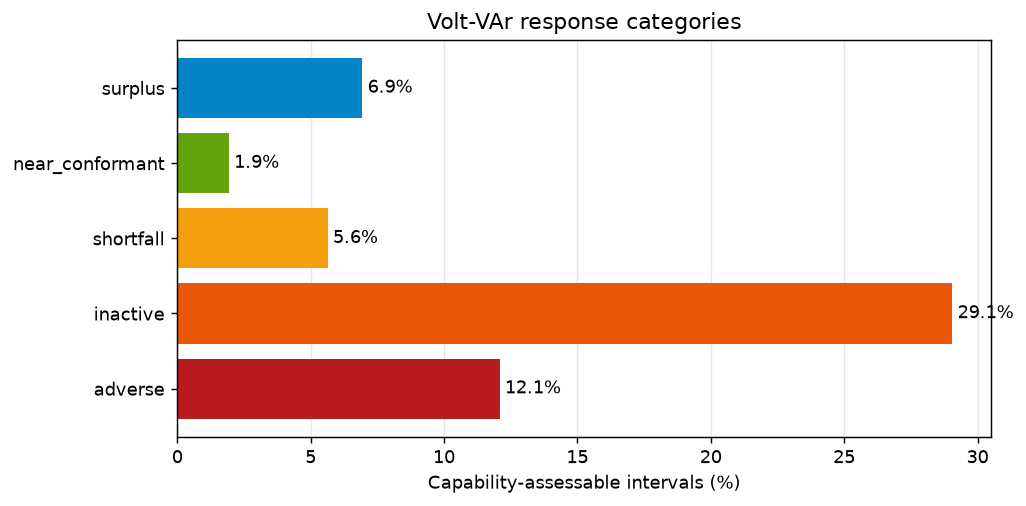

In [16]:
vvar_site_year = cq.fetch_vvar_site_year(aq, CONFIG)
vvar_sites = cm.prepare_vvar_conformance(vvar_site_year, CONFIG)
vvar_result = cm.fleet_result(
    vvar_sites, 'Volt-VAr capability-conditioned conformance',
    'Was measured Q within the required and capability-clamped band?',
    'capability-assessable intervals',
)
vvar_bands = cm.vvar_band_summary(vvar_site_year)
vvar_energy_site_year, vvar_energy_summary = cm.vvar_curtailment_summary(
    vvar_site_year, CONFIG.interval_h)
display(vvar_result)
display(vvar_bands)
display(vvar_energy_summary)
cp.plot_vvar_bands(vvar_bands);

## 6. State, DNSP, OEM, installation-year and time breakdowns


Volt-Watt by state


,state,n_sites,denominator_intervals,nonconforming_intervals,fleet_conformant_pct,fleet_any_nonconf_pct,interval_nonconf_pct
3,QLD,1990,3039947,609129,76.281407,38.693467,20.037487
5,TAS,74,47561,360,83.783784,31.081081,0.756923
2,NT,68,78623,4380,88.235294,27.941176,5.570889
4,SA,320,297732,32366,88.75,25.0,10.87085
1,NSW,1875,2786717,198334,89.173333,23.52,7.11712
7,WA,171,233010,21874,90.05848,18.128655,9.38758
0,ACT,80,49036,4576,92.5,18.75,9.331919
6,VIC,443,299664,1903,95.259594,13.769752,0.635045



Volt-Watt by dnsp


,dnsp,n_sites,denominator_intervals,nonconforming_intervals,fleet_conformant_pct,fleet_any_nonconf_pct,interval_nonconf_pct
5,Energex,614,292500,25600,75.570033,37.785016,8.752137
6,Ergon,1320,2822275,591121,76.742424,38.560606,20.944841
12,TasNetworks,70,47232,358,84.285714,30.0,0.757961
7,Essential,634,1148194,93852,86.59306,29.022082,8.17388
1,Ausgrid,849,1294994,90530,88.103651,24.028269,6.990766
11,SAPN,311,285336,31492,89.067524,24.115756,11.036813
13,Unknown,200,182978,14117,90.0,22.5,7.715135
4,Endeavour,458,395115,18375,91.703057,19.650655,4.650545
14,Western Power,37,17497,976,91.891892,10.810811,5.578099
0,Actewagl,80,49036,4576,92.5,18.75,9.331919



Volt-Watt by oem


...

,install_year,n_sites,denominator_intervals,nonconforming_intervals,fleet_conformant_pct,fleet_any_nonconf_pct,interval_nonconf_pct
4,2011,20,690130,424126,15.0,100.0,61.455958
11,2018,649,22628167,13603850,17.719569,97.842835,60.119098
12,2019,1785,57040780,34150117,17.871148,98.431373,59.869653
7,2014,33,1253525,777932,18.181818,100.0,62.059552
9,2016,196,5672601,3020917,19.387755,96.938776,53.25453
13,2020,2876,128269876,72822571,20.862309,97.739917,56.772933
10,2017,320,10662574,5892090,20.9375,98.4375,55.259546
18,2025,1112,18743532,9853712,24.730216,92.086331,52.571266
14,2021,2695,129938860,68874176,26.048237,97.662338,53.005064
8,2015,92,2913895,1638717,27.173913,94.565217,56.238025



Volt-Watt curtailed energy by DNSP


,dnsp,n_sites,sites_with_curtailment,curtailed_kwh,median_site_kwh
6,Ergon,3372,405,4215.910750,0.0
7,Essential,1532,188,1483.515993,0.0
1,Ausgrid,2715,240,994.568208,0.0
4,Endeavour,1949,80,461.183139,0.0
5,Energex,2548,103,368.618000,0.0
12,SAPN,1236,78,353.699586,0.0
14,Unknown,514,50,176.302199,0.0
11,Powercor,414,29,104.412854,0.0
2,Ausnet,417,32,102.942096,0.0
15,Western Power,122,6,64.373396,0.0



Volt-VAr curtailed energy by DNSP


,dnsp,n_sites,sites_with_curtailment,curtailed_kwh,median_site_kwh
6,Ergon,3424,458,47.531332,0.0
7,Essential,1552,215,41.143991,0.0
5,Energex,2596,362,28.534849,0.0
1,Ausgrid,2757,308,21.025905,0.0
13,TasNetworks,362,92,7.913982,0.0
4,Endeavour,1995,137,7.121894,0.0
2,Ausnet,427,52,6.173263,0.0
11,Powercor,422,56,5.640552,0.0
12,SAPN,1246,45,2.558348,0.0
9,Jemena,136,17,2.183342,0.0


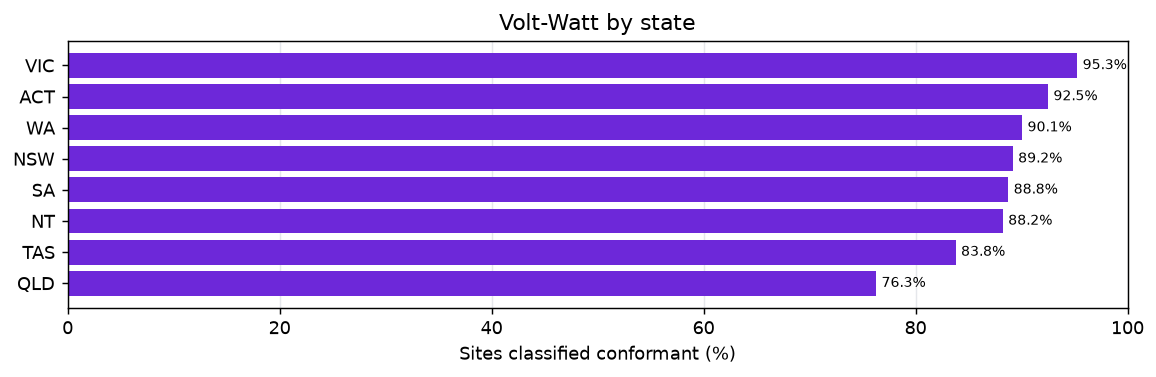

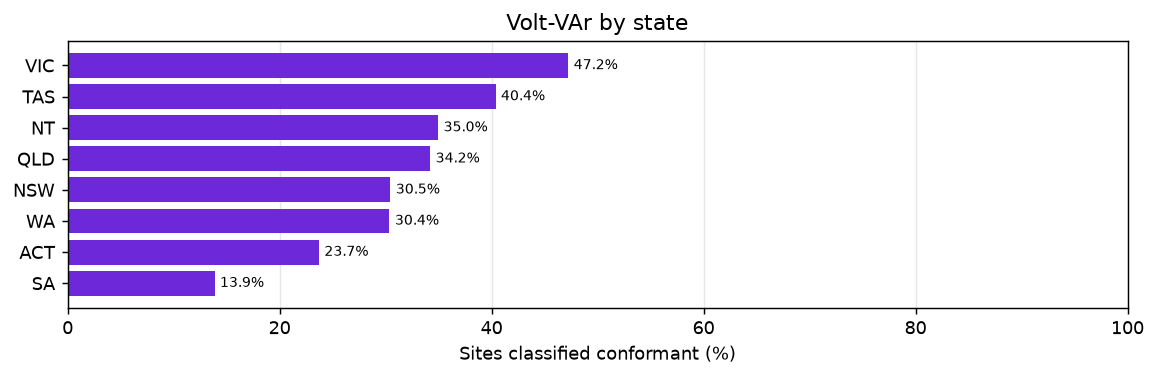

In [17]:
breakdowns = {}
for mechanism, frame in [('Volt-Watt', vw_sites), ('Volt-VAr', vvar_sites)]:
    for group in ('state', 'dnsp', 'oem', 'install_year'):
        key = (mechanism, group)
        breakdowns[key] = cm.group_breakdown(frame, meta, group, min_sites=20)
        print(f'\n{mechanism} by {group}')
        display(breakdowns[key])

cp.plot_group_breakdown(breakdowns[('Volt-Watt','state')], 'state', 'Volt-Watt by state')
cp.plot_group_breakdown(breakdowns[('Volt-VAr','state')], 'state', 'Volt-VAr by state')

vw_energy_breakdowns = {g: cm.energy_group_breakdown(vw_energy_sites, meta, g, min_sites=20)
                        for g in ('state','dnsp','oem','install_year')}
vvar_energy_breakdowns = {g: cm.energy_group_breakdown(vvar_energy_site_year, meta, g, min_sites=20)
                          for g in ('state','dnsp','oem','install_year')}
print('\nVolt-Watt curtailed energy by DNSP')
display(vw_energy_breakdowns['dnsp'])
print('\nVolt-VAr curtailed energy by DNSP')
display(vvar_energy_breakdowns['dnsp'])

### Volt-Watt nonconformance magnitude by fleet group

The following breakdowns supplement the frequency-based site classifications with the normalised magnitude of excess active power.

The mean and median site metrics give each site equal weight. The fleet-weighted metric divides total nonconformance Wh by total capacity-interval exposure, so systems with more exposed observations and greater nameplate capacity contribute proportionally more weight.

In [18]:
vw_normalized_breakdowns = {}

for group in ("state", "dnsp", "oem", "install_year"):
    vw_normalized_breakdowns[group] = (
        cm.vw_normalized_group_breakdown(
            vw_sites,
            meta,
            group,
            CONFIG.interval_h,
            capacity_col="ac_capacity_kw",
            min_sites=20,
        )
    )

    print(f"\nVolt-Watt normalised nonconformance by {group}")
    display(vw_normalized_breakdowns[group])


Volt-Watt normalised nonconformance by state


,state,n_sites,fleet_conformant_pct,fleet_any_nonconf_pct,total_nonconformance_wh,total_capacity_interval_exposure_kw,mean_site_normalized_nc,median_site_normalized_nc,fleet_weighted_normalized_nc_wh_per_kw_interval
3,QLD,1990,76.281407,38.693467,1.005140e+08,28845107.22,3.528481,0.0,3.484613
4,SA,320,88.75,25.0,3.618548e+06,2082862.55,0.606750,0.0,1.737296
1,NSW,1875,89.173333,23.52,2.245813e+07,27512747.59,0.628750,0.0,0.816281
0,ACT,80,92.5,18.75,2.112852e+05,343259.8,0.159180,0.0,0.615526
7,WA,171,90.05848,18.128655,2.138579e+06,4276534.48,0.459139,0.0,0.500073
2,NT,68,88.235294,27.941176,1.428144e+05,471240.8,0.136377,0.0,0.30306
6,VIC,443,95.259594,13.769752,1.114162e+05,2626403.63,0.498888,0.0,0.042422
5,TAS,74,83.783784,31.081081,1.444107e+04,350839.5,2.545321,0.0,0.041161



Volt-Watt normalised nonconformance by dnsp


,dnsp,n_sites,fleet_conformant_pct,fleet_any_nonconf_pct,total_nonconformance_wh,total_capacity_interval_exposure_kw,mean_site_normalized_nc,median_site_normalized_nc,fleet_weighted_normalized_nc_wh_per_kw_interval
6,Ergon,1320,76.742424,38.560606,1.005357e+08,29437461.65,2.453494,0.0,3.415229
11,SAPN,311,89.067524,24.115756,3.575999e+06,1898523.55,0.434084,0.0,1.883569
7,Essential,634,86.59306,29.022082,1.155949e+07,11063216.88,0.853536,0.0,1.044858
1,Ausgrid,849,88.103651,24.028269,9.675519e+06,11141874.09,1.246878,0.0,0.868392
0,Actewagl,80,92.5,18.75,2.112852e+05,343259.8,0.159180,0.0,0.615526
5,Energex,614,75.570033,37.785016,1.373540e+06,2511625.07,5.616869,0.0,0.546873
13,Unknown,200,90.0,22.5,4.643718e+05,1196260.68,0.163616,0.0,0.388186
4,Endeavour,458,91.703057,19.650655,1.662050e+06,5809984.62,0.268479,0.0,0.286068
14,Western Power,37,91.891892,10.810811,2.574014e+04,130468.3,0.148877,0.0,0.19729
15,united energy,93,96.774194,6.451613,1.062376e+04,173128.24,0.131460,0.0,0.061364



Volt-Watt normalised nonconformance by oem


,oem,n_sites,fleet_conformant_pct,fleet_any_nonconf_pct,total_nonconformance_wh,total_capacity_interval_exposure_kw,mean_site_normalized_nc,median_site_normalized_nc,fleet_weighted_normalized_nc_wh_per_kw_interval
11,GoodWe,736,80.298913,33.831522,6.943867e+07,14192358.2,0.939114,0.0,4.89268
9,Generic Inverter,1671,78.635548,35.18851,2.437042e+07,15414902.91,4.370427,0.0,1.580965
7,Fronius,847,83.943329,29.988194,1.223763e+07,9036870.5,0.626900,0.0,1.354189
27,Sungrow,833,88.47539,23.769508,2.120076e+07,18407841.18,0.289095,0.0,1.151724
26,Solis,57,89.473684,22.807018,6.195670e+05,623989.1,0.339054,0.0,0.992913
29,Zeversolar,25,96.0,24.0,5.855545e+04,137587.0,0.105024,0.0,0.425589
12,Growatt,24,91.666667,33.333333,5.289093e+04,135189.0,0.234493,0.0,0.391237
24,SolaX,175,97.714286,13.142857,1.180927e+05,704486.3,0.060469,0.0,0.167629
19,SMA,365,94.794521,15.342466,4.500398e+05,3705576.0,0.233284,0.0,0.121449
0,ABB,66,98.484848,21.212121,1.101469e+05,1944858.9,0.032618,0.0,0.056635



Volt-Watt normalised nonconformance by install_year


,install_year,n_sites,fleet_conformant_pct,fleet_any_nonconf_pct,total_nonconformance_wh,total_capacity_interval_exposure_kw,mean_site_normalized_nc,median_site_normalized_nc,fleet_weighted_normalized_nc_wh_per_kw_interval
13,2022,662,83.685801,27.34139,4.701894e+07,10103164.06,0.749078,0.0,4.653882
9,2018,143,90.20979,24.475524,3.150839e+06,753481.58,0.379690,0.0,4.181707
11,2020,921,86.319218,26.60152,2.126662e+07,9196892.95,0.547371,0.0,2.312371
12,2021,882,86.281179,28.117914,3.886957e+07,19627915.48,0.537153,0.0,1.980321
15,2024,864,75.115741,41.550926,1.162285e+07,9728709.87,5.574822,0.0,1.194696
10,2019,473,90.697674,18.816068,1.688762e+06,2477788.76,0.291926,0.0,0.68156
16,2025,265,95.471698,16.226415,6.022493e+05,1302453.49,0.192403,0.0,0.462396
14,2023,663,81.900452,30.015083,4.662391e+06,11081679.87,3.528610,0.0,0.42073
7,2016,44,93.181818,29.545455,3.399081e+04,90044.6,0.112029,0.0,0.377489
8,2017,61,86.885246,26.229508,1.091041e+05,774406.61,0.203420,0.0,0.140887


### Monthly thread

,year,month,n_sites,nonconf_count,denominator_count,interval_nonconf_pct,period
0,2024,1,1506,34532,266418,12.961587,2024-01-01
1,2024,2,1596,33866,264589,12.799474,2024-02-01
2,2024,3,1554,34171,284960,11.991508,2024-03-01
3,2024,4,1554,32713,323838,10.101656,2024-04-01
4,2024,5,1458,18923,245661,7.702891,2024-05-01
5,2024,6,1333,23512,262429,8.959376,2024-06-01
6,2024,7,1369,25792,272080,9.479565,2024-07-01
7,2024,8,1645,45502,370813,12.270875,2024-08-01
8,2024,9,1693,60596,441023,13.739873,2024-09-01
9,2024,10,1714,88290,495254,17.827216,2024-10-01


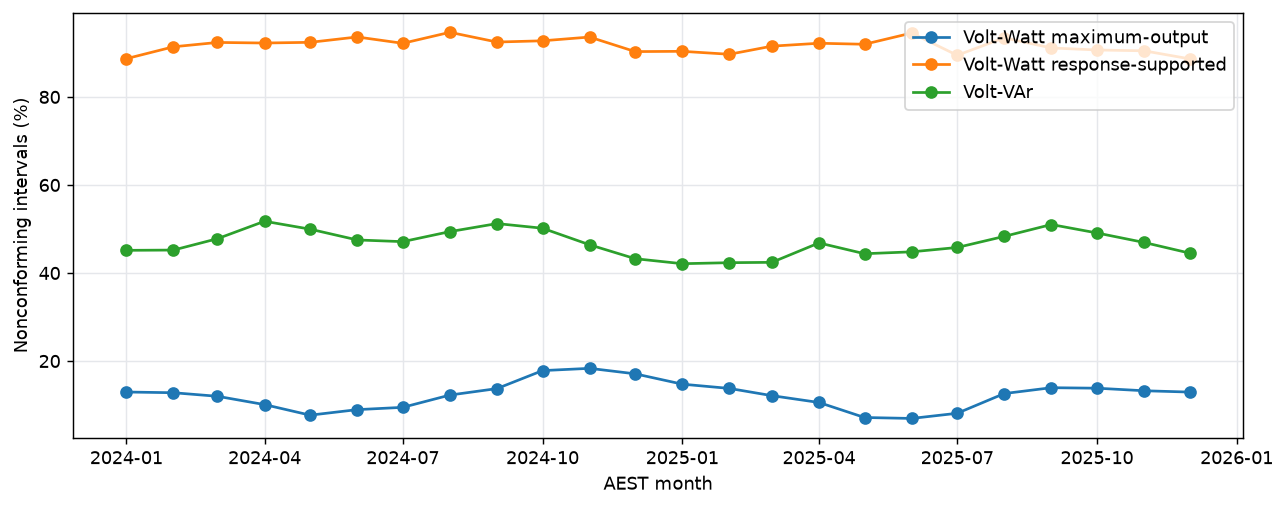

In [19]:
monthly_vw = cm.monthly_rates(cq.fetch_monthly_fleet(aq, CONFIG, 'vw'))
monthly_vwg = cm.monthly_rates(cq.fetch_monthly_fleet(aq, CONFIG, 'vw_response'))
monthly_vvar = cm.monthly_rates(cq.fetch_monthly_fleet(aq, CONFIG, 'vvar'))
display(monthly_vw)
cp.plot_monthly_rates(('Volt-Watt maximum-output', monthly_vw),
                      ('Volt-Watt response-supported', monthly_vwg),
                      ('Volt-VAr', monthly_vvar));

## 7. Legacy reconciliation and reporting-ready tally

In [20]:
legacy_by_year = cq.fetch_legacy_population_by_year(aq, CONFIG)
legacy_membership = cq.fetch_original_v2_membership(aq, CONFIG)
display(legacy_by_year)
display(legacy_membership)
print('Do not add yearly site counts: sites can appear in both years.')

,year,voltage_exposed_sites,review_corrected_sites,legacy_like_sites
0,2024,3648,1301,2760
1,2025,3510,1386,2464


,cohort,n_sites
0,original_basic,5021
1,original_ghi,5021
2,v2_basic,16148
3,v2_ghi_counterfactual_present,3637
4,v2_ghi_response_supported,1971


Do not add yearly site counts: sites can appear in both years.


,metric,question,denominator,n_sites_contained_in_table,n_assessed_sites,n_intervals,n_nonconforming_intervals,interval_nonconf_pct,fleet_conformant_pct,fleet_any_nonconf_pct
0,Volt-Watt maximum-output conformance,Did measured P exceed the voltage-dependent ma...,voltage-exposed intervals (V > 253 V),16148,5021,6832290,872922,12.776419,84.564828,28.679546
1,Volt-Watt response-supported result,Was enough solar power available to test the r...,response-supported intervals,16148,1971,951407,872922,91.750639,31.100964,73.059361
2,Volt-VAr capability-conditioned conformance,Was measured Q within the required and capabil...,capability-assessable intervals,16148,16148,647972108,302988577,46.759509,32.164974,95.764181


,result,question_answered,principal_limitation
0,Volt-Watt maximum-output,Primary standards-oriented maximum-output test,Counterfactual not required; below ceiling doe...
1,Volt-Watt response-supported,Evidence that the response had an opportunity ...,Narrower GHI-supported population; not the pri...
2,Volt-Watt curtailed energy,Estimated generation displaced,Only counterfactual-covered intervals
3,Volt-VAr conformance,Required Q conditional on implemented capabili...,S_rated is proxied by the recorded rating basis
4,Volt-VAr curtailment,Headline only here; causal evidence is in note...,"S_99 is empirical, not verified manufacturer S..."


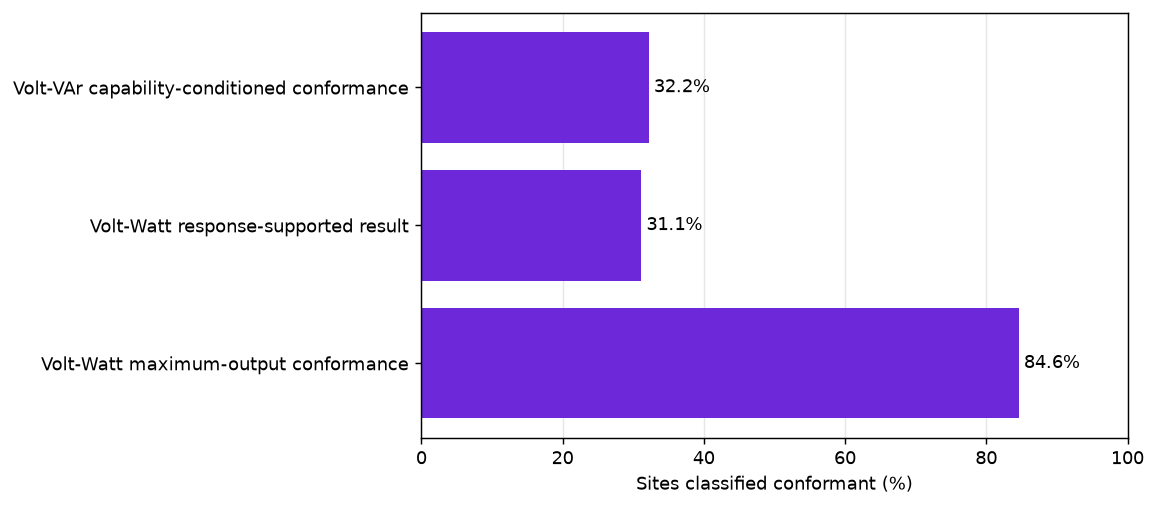

In [21]:
headline_results = cm.reporting_tally(vw_result, vwg_result, vvar_result)
display(headline_results)
cp.plot_fleet_summary(headline_results);

reporting_notes = pd.DataFrame([
    ['Volt-Watt maximum-output', 'Primary standards-oriented maximum-output test', 'Counterfactual not required; below ceiling does not prove active response'],
    ['Volt-Watt response-supported', 'Evidence that the response had an opportunity to operate', 'Narrower GHI-supported population; not the primary compliance denominator'],
    ['Volt-Watt curtailed energy', 'Estimated generation displaced', 'Only counterfactual-covered intervals'],
    ['Volt-VAr conformance', 'Required Q conditional on implemented capability floor', 'S_rated is proxied by the recorded rating basis'],
    ['Volt-VAr curtailment', 'Headline only here; causal evidence is in notebook 03', 'S_99 is empirical, not verified manufacturer S_rated'],
], columns=['result', 'question_answered', 'principal_limitation'])
display(reporting_notes)

## 7. Legacy reconciliation

### Why the legacy and v2 Volt-Watt GHI results differ

The prior ARENA Milestone 3 report (Section 2.2) presents Volt-Watt conformance from the legacy `conformance_voltwattghi` table. 

The v2 rebuild produces different counts.
Two defects in the legacy Stage 1 counterfactual table are the cause.

**Issue 1: Counterfactual duplicate rows (primary driver).**
`voltwatt_uncurtailedPV` contains 5.3M rows but only 2.7M unique
(site_id, t_stamp) pairs, with 94.9% of pairs are duplicated exactly once. 

The legacy GHI builder's `LEFT JOIN` fans out each matched telemetry interval to two scored rows, inflating nonconformance counts. 

Proof: legacy GHI NC for January 2024 (46,056) exceeds legacy *basic* NC for the same month (34,579).
This is logically impossible without fan-out, the GHI gate can only remove intervals, never add them. The v2 tables show GHI NC = basic NC (34,532), confirming no fan-out.

**Defect 2: Limited counterfactual coverage (secondary).**
The legacy counterfactual covers 3,301 of ~16,000 sites. 

For the remaining ~12,500 sites, the LEFT JOIN gives `uncurtailed_P = NULL`, and the scoring rule (`WHEN uncurtailed_P > max_P OR uncurtailed_P IS NULL`) treats every voltage-exposed interval as assessable, effectively running basic V-Watt (no irradiance filtering) for ~80% of the fleet.  The v2 counterfactual covers 15,888 sites (504M rows), so the irradiance filter operates fleet-wide.

**Eliminated hypotheses:**

| Factor | Finding |
|---|---|
| Voltage aggregation | Both use `avg(voltage)` |
| Tolerance | Both use `+4% × ac_capacity_kw` |
| Metadata fan-out | 0 excess rows in `meta_up23c` |
| Telemetry data changes | Raw recomputation matches legacy basic exactly |
| `s_99` filter | Removes 0 circuits |
| Legacy conformance table duplicates | 0 duplicated site-days |


In [ ]:
# Issue 1: duplicate (site_id, t_stamp) pairs in legacy counterfactual
cf_dup = aq("""
WITH pairs AS (
    SELECT site_id, t_stamp, COUNT(*) AS n
    FROM voltwatt_uncurtailedPV
    GROUP BY site_id, t_stamp
)
SELECT
    COUNT(*)                                AS total_pairs,
    SUM(CASE WHEN n > 1 THEN 1 ELSE 0 END) AS duplicated_pairs,
    SUM(n - 1)                              AS excess_rows,
    MAX(n)                                  AS max_dups_per_pair
FROM pairs
""", database=CONFIG.database)
print("=== Legacy counterfactual duplicate audit ===")
display(cf_dup)

# Defect 2: coverage gap
legacy_cf_summary = aq("""
SELECT COUNT(*) AS total_rows, COUNT(DISTINCT site_id) AS n_sites,
       MIN(t_stamp) AS earliest, MAX(t_stamp) AS latest
FROM voltwatt_uncurtailedPV
""", database=CONFIG.database)

v2_cf_summary = aq(f"""
SELECT COUNT(*) AS total_rows, COUNT(DISTINCT site_id) AS n_sites,
       MIN(year_p) AS first_year, MAX(year_p) AS last_year
FROM {CONFIG.tables['all_uncurtailedpv']}
""", database=CONFIG.database)

print("\nLegacy counterfactual (voltwatt_uncurtailedPV):")
display(legacy_cf_summary)
print(f"\nV2 counterfactual ({CONFIG.tables['all_uncurtailedpv']}):")
display(v2_cf_summary)

# Proof of fan-out: GHI NC > basic NC in January 2024
jan_proof = aq("""
SELECT 'legacy_basic' AS source,
       SUM(nonconformance_voltwatt_count) AS nc, SUM(total_count) AS denominator
FROM conformance_voltwatt WHERE year = 2024 AND month = 1
UNION ALL
SELECT 'legacy_ghi',
       SUM(nonconformance_voltwattghi_count), SUM(total_count)
FROM conformance_voltwattghi WHERE year = 2024 AND month = 1
""", database=CONFIG.database)
print("\nJan 2024 fan-out proof (GHI NC > basic NC is impossible without fan-out):")
display(jan_proof)

=== Legacy counterfactual duplicate audit ===


,total_pairs,duplicated_pairs,excess_rows,max_dups_per_pair
0,2714777,2575218,2575218,2



Legacy counterfactual (voltwatt_uncurtailedPV):


,total_rows,n_sites,earliest,latest
0,5289995,3301,2024-01-01,2025-12-31 23:55:00



V2 counterfactual (all_uncurtailedpv_v2_flex_included):


,total_rows,n_sites,first_year,last_year
0,504416916,15888,2024,2025



Jan 2024 fan-out proof (GHI NC > basic NC is impossible without fan-out):


,source,nc,denominator
0,legacy_basic,34579,268191
1,legacy_ghi,46056,201600


In [23]:

legacy_vw_sites = cq.fetch_legacy_vw_site(aq, CONFIG)

print(f"Legacy GHI table: {len(legacy_vw_sites):,} sites")
print(f"  with any nonconformance: {(legacy_vw_sites['nc_count'] > 0).sum():,}")
print(f"  total NC timestamps:     {legacy_vw_sites['nc_count'].sum():,}")
print(f"  total NC kWh:            {(legacy_vw_sites['nc_kw_sum'].sum() * CONFIG.interval_h):,.1f}")
print(f"\nNOTE: these counts are INFLATED by the counterfactual fan-out defect.")

for group in ("state", "dnsp", "oem"):
    legacy_bd = cm.legacy_vw_breakdown(
        legacy_vw_sites, meta, group, CONFIG.interval_h,
        capacity_col="ac_capacity_kw",
        threshold=0.10, min_sites=20,
    )
    print(f"\nLegacy V-Watt by {group} (inflated)")
    display(legacy_bd)


Legacy GHI table: 5,021 sites
  with any nonconformance: 1,440
  total NC timestamps:     1,226,500
  total NC kWh:            177,800.1

NOTE: these counts are INFLATED by the counterfactual fan-out defect.

Legacy V-Watt by state (inflated)


,state,n_sites,total_nc_timestamps,total_nc_kwh,mean_norm_nc_wh_kw,pct_nonconf_10pct,pct_any_nonconf
3,QLD,1990,848854,136529.331753,4.307031,26.432161,38.693467
5,TAS,74,383,16.406574,2.925569,20.270270,31.081081
1,NSW,1875,286270,32507.604713,0.882963,13.386667,23.52
4,SA,320,45124,5121.384223,0.816171,14.687500,25.0
7,WA,171,31021,3001.996255,0.638407,13.450292,18.128655
6,VIC,443,2348,129.905165,0.577228,5.869074,13.769752
0,ACT,80,6724,308.133369,0.345340,11.250000,18.75
2,NT,68,5776,185.373811,0.247548,14.705882,27.941176



Legacy V-Watt by dnsp (inflated)


,dnsp,n_sites,total_nc_timestamps,total_nc_kwh,mean_norm_nc_wh_kw,pct_nonconf_10pct,pct_any_nonconf
5,Energex,614,37502,2000.466013,6.427438,27.198697,37.785016
6,Ergon,1320,820762,136413.617283,3.183151,25.833333,38.560606
12,TasNetworks,70,380,15.765432,2.662879,20.000000,30.0
1,Ausgrid,849,127007,13258.643484,1.603866,14.252061,24.028269
7,Essential,634,139486,17746.689471,1.117836,16.561514,29.022082
11,SAPN,311,43866,5064.660193,0.628696,14.469453,24.115756
2,Ausnet,160,828,59.685564,0.543195,5.625000,16.25
4,Endeavour,458,26396,2140.556828,0.525193,10.698690,19.650655
10,Powercor,128,1267,50.940563,0.487980,8.593750,15.625
0,Actewagl,80,6724,308.133369,0.345340,11.250000,18.75



Legacy V-Watt by oem (inflated)


,oem,n_sites,total_nc_timestamps,total_nc_kwh,mean_norm_nc_wh_kw,pct_nonconf_10pct,pct_any_nonconf
9,Generic Inverter,1671,232747,34401.656817,5.122559,24.057451,35.18851
11,GoodWe,736,481860,93101.883316,1.490667,22.826087,33.831522
7,Fronius,847,210726,17066.991069,0.920234,19.598583,29.988194
26,Solis,57,4935,657.716992,0.644119,10.526316,22.807018
27,Sungrow,833,263252,30827.521525,0.458602,13.685474,23.769508
12,Growatt,24,2249,71.064943,0.429969,12.500000,33.333333
19,SMA,365,12759,616.767352,0.334354,7.123288,15.342466
29,Zeversolar,25,1370,85.090089,0.245664,4.000000,24.0
13,Huawei,65,499,16.616585,0.112896,6.153846,15.384615
24,SolaX,175,3236,127.206292,0.109464,4.000000,13.142857


In [24]:

legacy_cf_site_ids = aq("""
    SELECT DISTINCT site_id FROM voltwatt_uncurtailedPV
""", database=CONFIG.database)

v2_ghi_by_site = vwg_site_year.groupby("site_id", as_index=False).agg(
    nc_count=("nonconf_count", "sum"),
    exposed_count=("exposed_count", "sum"),
    response_supported_count=("response_supported_count", "sum"),
)

v2_restricted = v2_ghi_by_site.merge(legacy_cf_site_ids, on="site_id", how="inner")

print("=== V2 GHI results restricted to legacy counterfactual sites ===")
print(f"V2 GHI all sites:               {len(v2_ghi_by_site):>6,} sites, "
      f"{v2_ghi_by_site['nc_count'].sum():>10,} NC timestamps")
print(f"V2 GHI legacy-CF-sites only:    {len(v2_restricted):>6,} sites, "
      f"{v2_restricted['nc_count'].sum():>10,} NC timestamps")
print(f"Legacy GHI (inflated by fan-out): {len(legacy_vw_sites):>6,} sites, "
      f"{legacy_vw_sites['nc_count'].sum():>10,} NC timestamps")


=== V2 GHI results restricted to legacy counterfactual sites ===
V2 GHI all sites:               16,148 sites,    872,922 NC timestamps
V2 GHI legacy-CF-sites only:     3,301 sites,    738,922 NC timestamps
Legacy GHI (inflated by fan-out):  5,021 sites,  1,226,500 NC timestamps


In [ ]:
print("=== V2 primary vs legacy (state) ===\n")

v2_state = cm.vw_nonconformance_magnitude_breakdown(
    vw_sites, meta, "state", CONFIG.interval_h,
    capacity_col="ac_capacity_kw", min_sites=20,
)

legacy_state = cm.legacy_vw_breakdown(
    legacy_vw_sites, meta, "state", CONFIG.interval_h,
    capacity_col="ac_capacity_kw", threshold=0.10, min_sites=20,
)

comparison = v2_state[["state", "n_sites", "nonconforming_intervals", "nonconforming_kwh"]].merge(
    legacy_state[["state", "n_sites", "total_nc_timestamps", "total_nc_kwh"]],
    on="state", how="outer", suffixes=("_v2", "_legacy"),
)
display(comparison)
print("\nLegacy counts are inflated by the 94.9% duplicate rate in voltwatt_uncurtailedPV.")
print("V2 counts are the primary, correct result.")


=== V2 primary vs legacy (state) ===



,state,n_sites_v2,nonconforming_intervals,nonconforming_kwh,n_sites_legacy,total_nc_timestamps,total_nc_kwh
0,ACT,80,4576,211.285235,80,6724,308.133369
1,NSW,1875,198334,22458.125953,1875,286270,32507.604713
2,NT,68,4380,142.814400,68,5776,185.373811
3,QLD,1990,609129,100514.046850,1990,848854,136529.331753
4,SA,320,32366,3618.548473,320,45124,5121.384223
5,TAS,74,360,14.441070,74,383,16.406574
6,VIC,443,1903,111.416158,443,2348,129.905165
7,WA,171,21874,2138.578675,171,31021,3001.996255



Legacy counts are inflated by the 94.9% duplicate rate in voltwatt_uncurtailedPV.
V2 counts are the primary, correct result.


In [27]:
SAI = "solar_analytics_iceberg"

fanout_proof = aq("""
WITH basic_by_state AS (
    SELECT m.state,
           SUM(b.nonconformance_voltwatt_count) AS basic_nc
    FROM conformance_voltwatt b
    JOIN (SELECT site_id, MAX(state) AS state
          FROM meta_up23c WHERE is_pv = True GROUP BY site_id) m
        USING (site_id)
    WHERE b.year IN (2024, 2025)
    GROUP BY m.state
),
ghi_by_state AS (
    SELECT m.state,
           SUM(g.nonconformance_voltwattghi_count) AS ghi_nc
    FROM conformance_voltwattghi g
    JOIN (SELECT site_id, MAX(state) AS state
          FROM meta_up23c WHERE is_pv = True GROUP BY site_id) m
        USING (site_id)
    WHERE g.year IN (2024, 2025)
    GROUP BY m.state
)
SELECT b.state,
       b.basic_nc,
       g.ghi_nc,
       g.ghi_nc - b.basic_nc AS phantom_nc,
       ROUND(100.0 * (g.ghi_nc - b.basic_nc) / b.basic_nc, 1) AS phantom_pct
FROM basic_by_state b
JOIN ghi_by_state g ON b.state = g.state
ORDER BY phantom_nc DESC
""", database=SAI)
display(fanout_proof)

,state,basic_nc,ghi_nc,phantom_nc,phantom_pct
0,QLD,609139,848854,239715,39.4
1,NSW,198340,286270,87930,44.3
2,SA,32404,45124,12720,39.3
3,WA,21874,31021,9147,41.8
4,ACT,4576,6724,2148,46.9
5,NT,4380,5776,1396,31.9
6,VIC,1903,2348,445,23.4
7,TAS,360,383,23,6.4
